# Task 5: Personal Loan Acceptance Prediction
**Internship Task, Developers Hub Corporation**

**Objective:** Predict which customers are likely to accept a personal loan offer using the Bank Marketing Dataset.

**Dataset:** Bank Marketing Dataset 

**Models Used:** Logistic Regression, Decision Tree Classifier

**Author:** Aiman Ishaq

## 1. Import Libraries

In [30]:

import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

# Settings
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('All libraries imported successfully.')

All libraries imported successfully.


## 2. Dataset Understanding and Description

The **Bank Marketing Dataset** is from a Portuguese bank's direct marketing campaigns (phone calls). The goal is to predict whether a client will subscribe to a term deposit (`y` column: yes/no).



In [ ]:

df = pd.read_csv("bank.csv")

print('Dataset Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Dataset Shape: (11162, 17)

First 5 rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [32]:

print('Dataset Info:')
df.info()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        11162 non-null  int64
 1   job        11162 non-null  str  
 2   marital    11162 non-null  str  
 3   education  11162 non-null  str  
 4   default    11162 non-null  str  
 5   balance    11162 non-null  int64
 6   housing    11162 non-null  str  
 7   loan       11162 non-null  str  
 8   contact    11162 non-null  str  
 9   day        11162 non-null  int64
 10  month      11162 non-null  str  
 11  duration   11162 non-null  int64
 12  campaign   11162 non-null  int64
 13  pdays      11162 non-null  int64
 14  previous   11162 non-null  int64
 15  poutcome   11162 non-null  str  
 16  deposit    11162 non-null  str  
dtypes: int64(7), str(10)
memory usage: 1.4 MB


In [33]:
# Statistical summary of numerical columns
print('Statistical Summary:')
df.describe()

Statistical Summary:


,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [34]:
# Check target variable distribution
print('Target Variable Distribution:')
print(df['deposit'].value_counts())
print('\nPercentage:')
print(df['deposit'].value_counts(normalize=True).mul(100).round(2))

Target Variable Distribution:
deposit
no     5873
yes    5289
Name: count, dtype: int64

Percentage:
deposit
no     52.62
yes    47.38
Name: proportion, dtype: float64


## 3. Data Cleaning and Preparation

In [35]:
# Check for missing values
print('Missing Values per Column:')
print(df.isnull().sum())
print('\nTotal missing values:', df.isnull().sum().sum())

Missing Values per Column:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

Total missing values: 0


In [36]:
# Check for duplicate rows
print('Duplicate rows:', df.duplicated().sum())

# Drop duplicates if any
df.drop_duplicates(inplace=True)
print('Shape after removing duplicates:', df.shape)

Duplicate rows: 0
Shape after removing duplicates: (11162, 17)


In [37]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print('Categorical columns:', categorical_cols)

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']


In [38]:
# Label encode all categorical columns
le = LabelEncoder()
df_encoded = df.copy()

for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])
    
print('Encoding complete.')
df_encoded.head()

Encoding complete.


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,0,1,1,0,2343,1,0,2,5,8,1042,1,-1,0,3,1
1,56,0,1,1,0,45,0,0,2,5,8,1467,1,-1,0,3,1
2,41,9,1,1,0,1270,1,0,2,5,8,1389,1,-1,0,3,1
3,55,7,1,1,0,2476,1,0,2,5,8,579,1,-1,0,3,1
4,54,0,1,2,0,184,0,0,2,5,8,673,2,-1,0,3,1


In [39]:
# Separate features (X) and target (y)
X = df_encoded.drop('deposit', axis=1)
y = df_encoded['deposit']

print('Features shape:', X.shape)
print('Target shape:', y.shape)

Features shape: (11162, 16)
Target shape: (11162,)


In [40]:
# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training set size:', X_train.shape)
print('Test set size:', X_test.shape)

Training set size: (8929, 16)
Test set size: (2233, 16)


## 4. Exploratory Data Analysis (EDA)

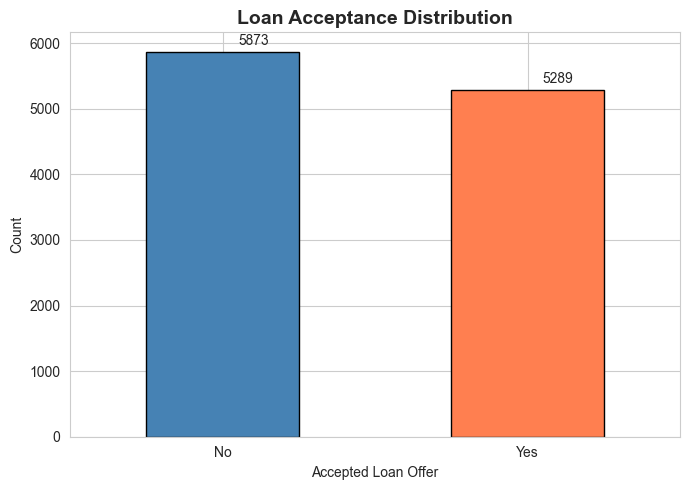

In [41]:
# 4.1 Target Variable — Class Balance
plt.figure(figsize=(7, 5))
ax = df['deposit'].value_counts().plot(kind='bar', color=['steelblue', 'coral'], edgecolor='black')
plt.title('Loan Acceptance Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Accepted Loan Offer')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'], rotation=0)
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + 0.3, p.get_height() + 100))
plt.tight_layout()
plt.show()

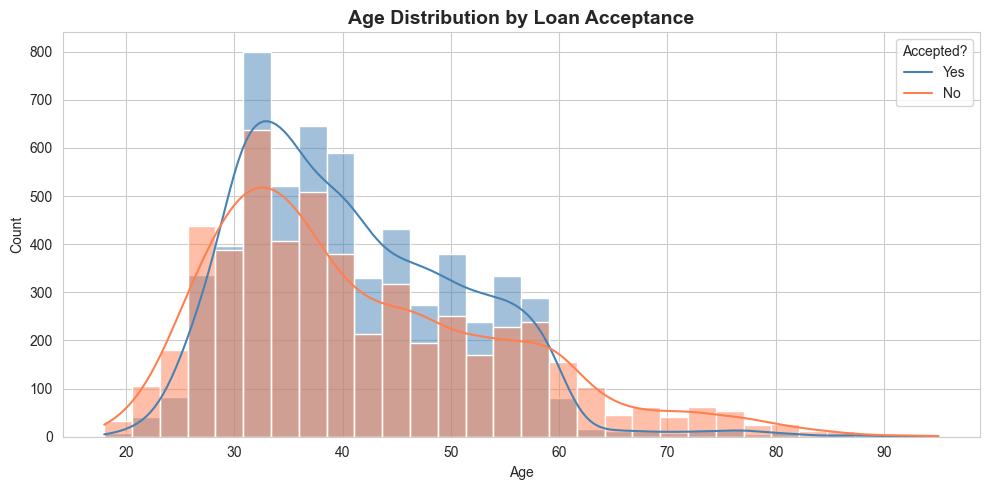

In [42]:
# 4.2 Age Distribution by Loan Acceptance
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='age', hue='deposit', kde=True, bins=30, palette={'no': 'steelblue', 'yes': 'coral'})
plt.title('Age Distribution by Loan Acceptance', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Accepted?', labels=['Yes', 'No'])
plt.tight_layout()
plt.show()

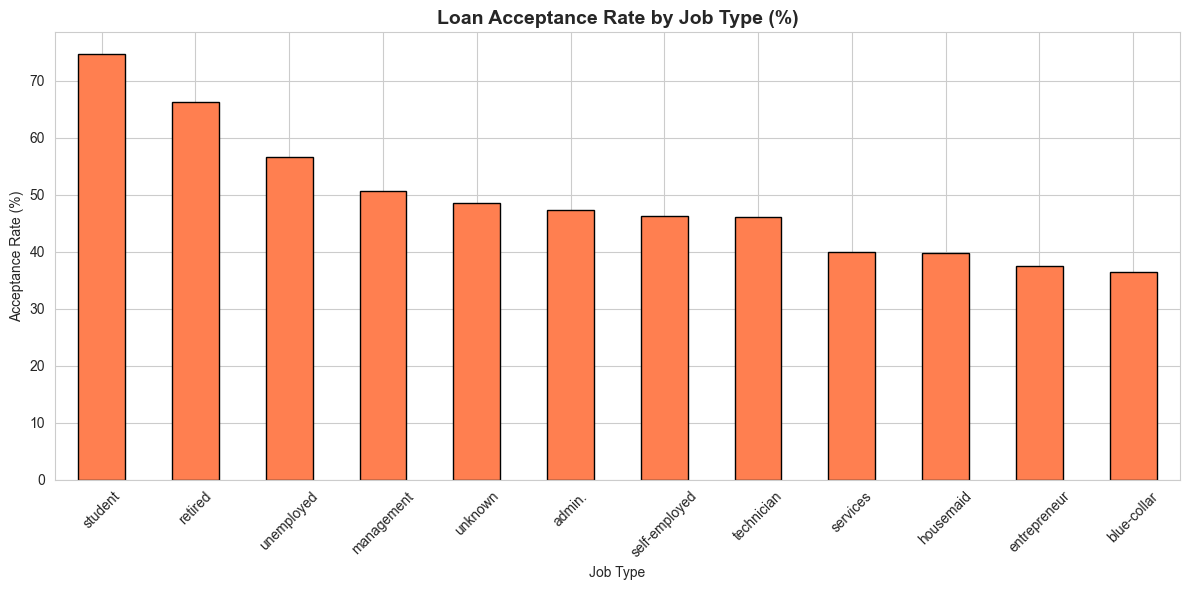

In [43]:
# 4.3 Job Type vs Loan Acceptance
plt.figure(figsize=(12, 6))
job_acceptance = df.groupby('job')['deposit'].value_counts(normalize=True).unstack().mul(100)
job_acceptance['yes'].sort_values(ascending=False).plot(kind='bar', color='coral', edgecolor='black')
plt.title('Loan Acceptance Rate by Job Type (%)', fontsize=14, fontweight='bold')
plt.xlabel('Job Type')
plt.ylabel('Acceptance Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

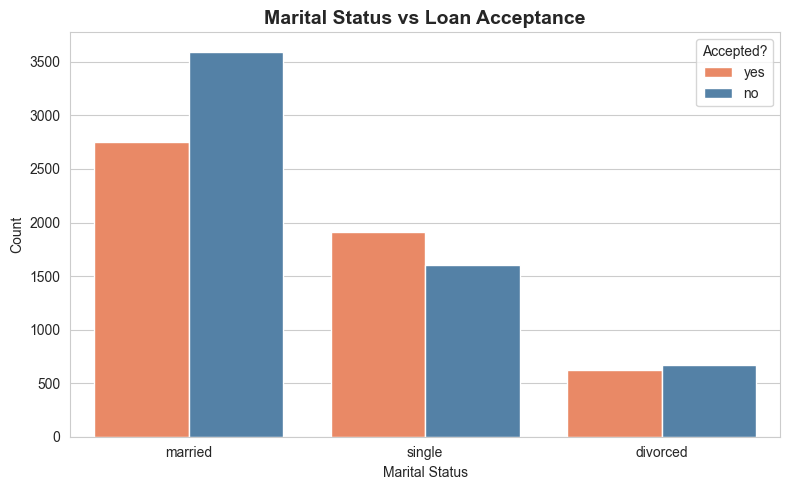

In [44]:
# 4.4 Marital Status vs Loan Acceptance
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='marital', hue='deposit', palette={'no': 'steelblue', 'yes': 'coral'})
plt.title('Marital Status vs Loan Acceptance', fontsize=14, fontweight='bold')
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.legend(title='Accepted?')
plt.tight_layout()
plt.show()

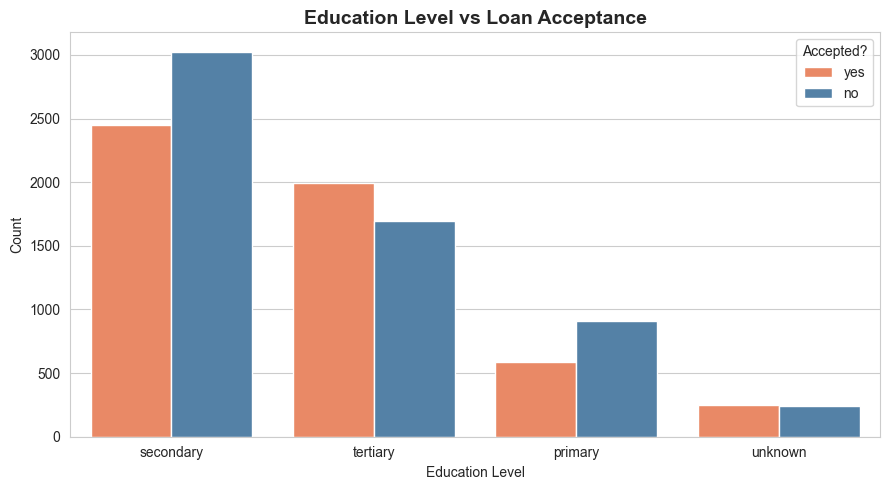

In [45]:
# 4.5 Education vs Loan Acceptance
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x='education', hue='deposit', palette={'no': 'steelblue', 'yes': 'coral'})
plt.title('Education Level vs Loan Acceptance', fontsize=14, fontweight='bold')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.legend(title='Accepted?')
plt.tight_layout()
plt.show()

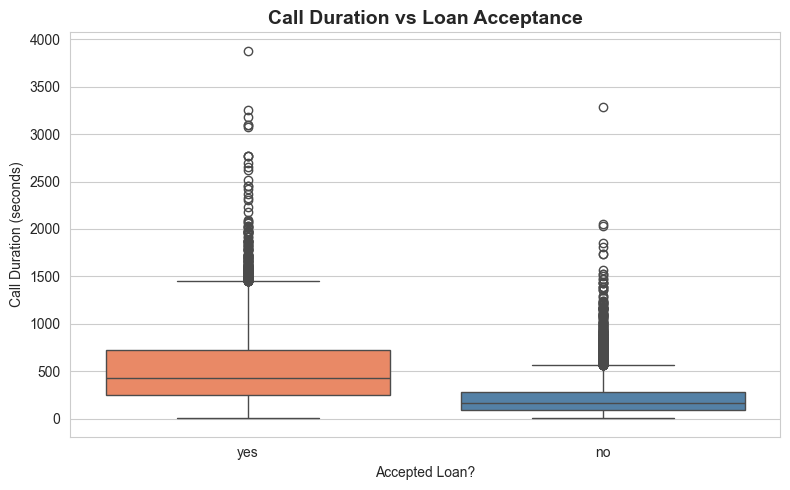

In [46]:
# 4.6 Call Duration vs Loan Acceptance (Box Plot)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='deposit', y='duration', palette={'no': 'steelblue', 'yes': 'coral'})
plt.title('Call Duration vs Loan Acceptance', fontsize=14, fontweight='bold')
plt.xlabel('Accepted Loan?')
plt.ylabel('Call Duration (seconds)')
plt.tight_layout()
plt.show()

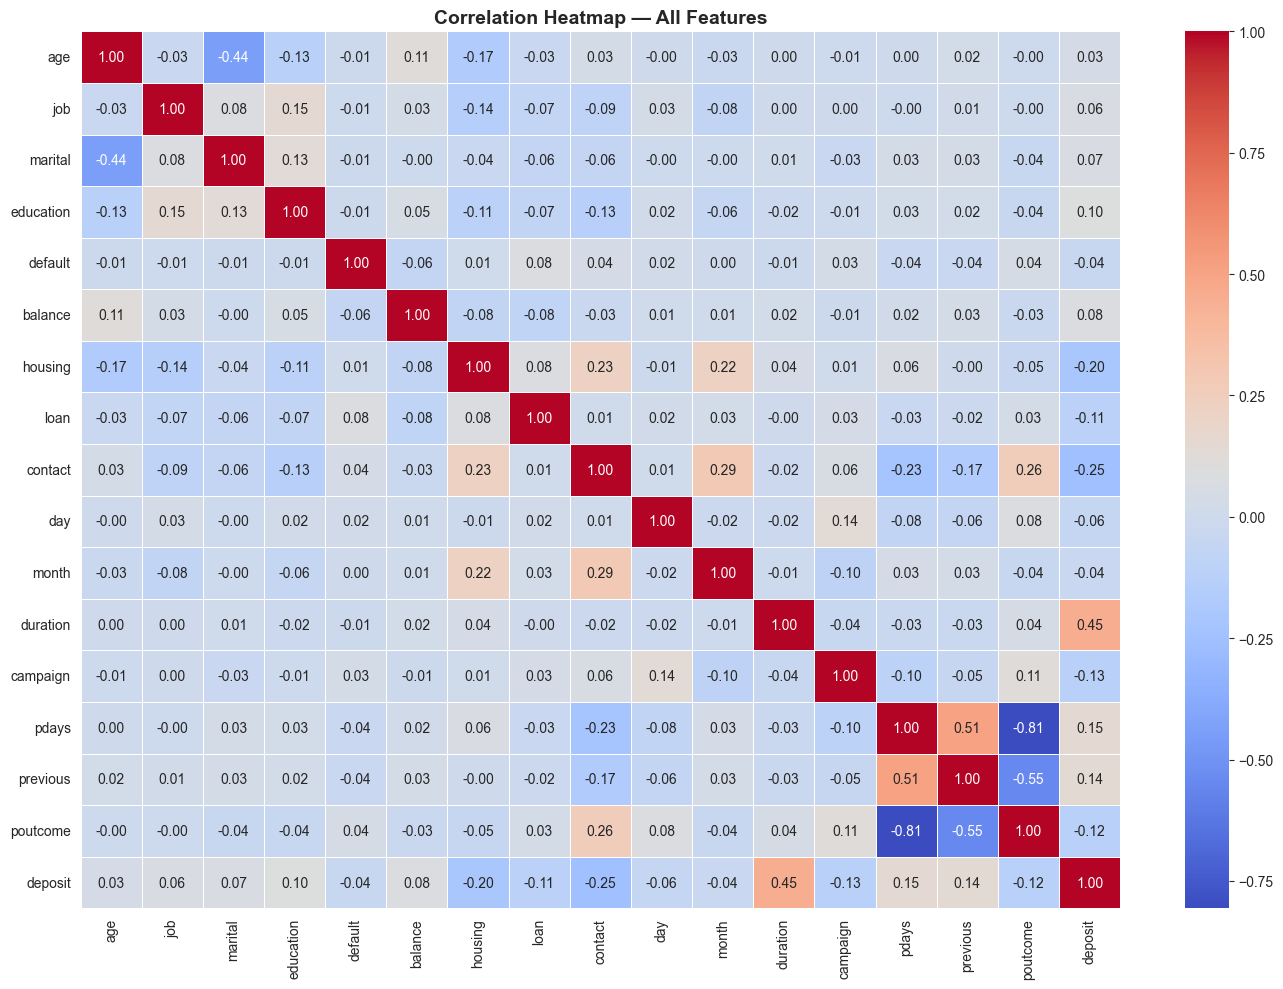


Top correlations with target (deposit):
deposit      1.000000
duration     0.451919
pdays        0.151593
previous     0.139867
education    0.095948
balance      0.081129
marital      0.067610
job          0.063395
age          0.034901
month       -0.037121
default     -0.040680
day         -0.056326
loan        -0.110580
poutcome    -0.122369
campaign    -0.128081
housing     -0.203888
contact     -0.249847
Name: deposit, dtype: float64


In [47]:
# 4.7 Correlation Heatmap
plt.figure(figsize=(14, 10))
corr = df_encoded.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap — All Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Show top correlations with target
print('\nTop correlations with target (deposit):')
print(corr['deposit'].sort_values(ascending=False))

## 5. Model Training and Testing

In [48]:
# 5.1 Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_pred)

print(f'Logistic Regression Accuracy: {lr_accuracy * 100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 78.59%

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.81      0.80      1175
           1       0.78      0.76      0.77      1058

    accuracy                           0.79      2233
   macro avg       0.79      0.78      0.78      2233
weighted avg       0.79      0.79      0.79      2233



In [49]:
# 5.2 Decision Tree Classifier
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_pred)

print(f'Decision Tree Accuracy: {dt_accuracy * 100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 80.70%

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.76      0.81      1175
           1       0.76      0.86      0.81      1058

    accuracy                           0.81      2233
   macro avg       0.81      0.81      0.81      2233
weighted avg       0.81      0.81      0.81      2233



## 6. Evaluation Metrics

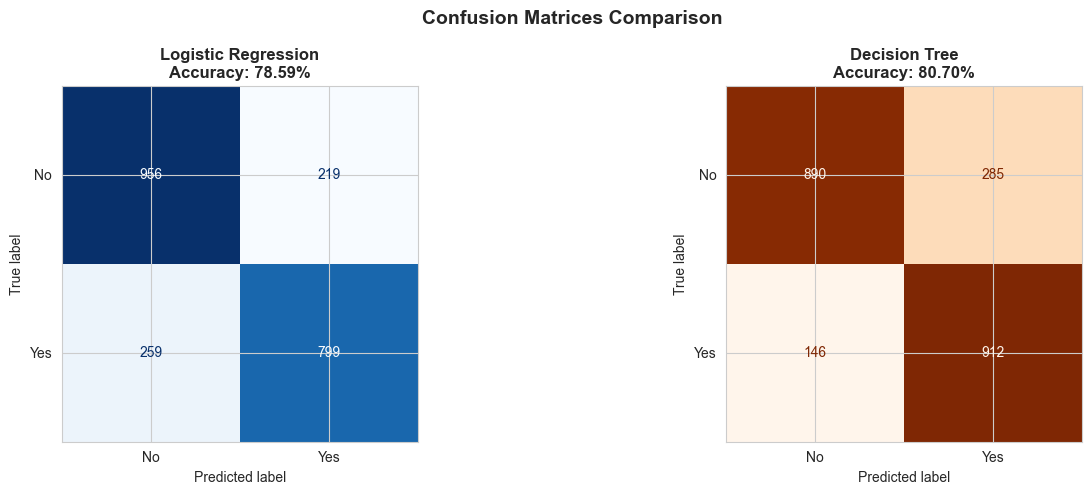

In [50]:
# 6.1 Confusion Matrices  Side by Side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression
ConfusionMatrixDisplay.from_predictions(
    y_test, lr_pred, ax=axes[0],
    display_labels=['No', 'Yes'],
    colorbar=False, cmap='Blues'
)
axes[0].set_title(f'Logistic Regression\nAccuracy: {lr_accuracy*100:.2f}%', fontweight='bold')

# Decision Tree
ConfusionMatrixDisplay.from_predictions(
    y_test, dt_pred, ax=axes[1],
    display_labels=['No', 'Yes'],
    colorbar=False, cmap='Oranges'
)
axes[1].set_title(f'Decision Tree\nAccuracy: {dt_accuracy*100:.2f}%', fontweight='bold')

plt.suptitle('Confusion Matrices Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

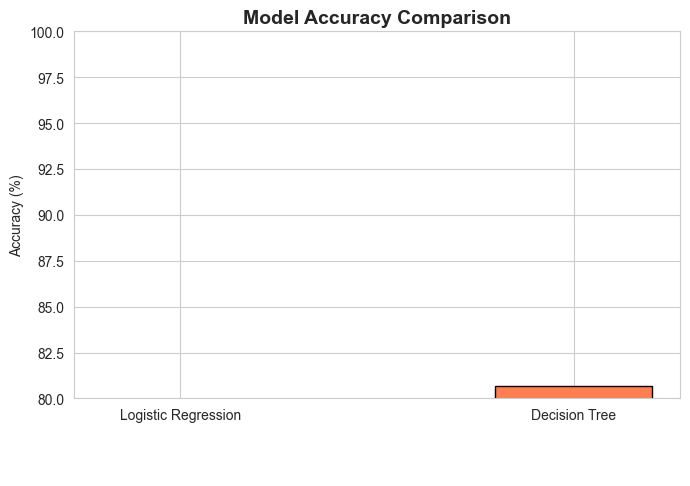

In [51]:
# 6.2 Model Accuracy Comparison Bar Chart
models = ['Logistic Regression', 'Decision Tree']
accuracies = [lr_accuracy * 100, dt_accuracy * 100]

plt.figure(figsize=(7, 5))
bars = plt.bar(models, accuracies, color=['steelblue', 'coral'], edgecolor='black', width=0.4)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 2,
             f'{acc:.2f}%', ha='center', va='top', color='white', fontweight='bold', fontsize=12)
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.ylim(80, 100)
plt.tight_layout()
plt.show()

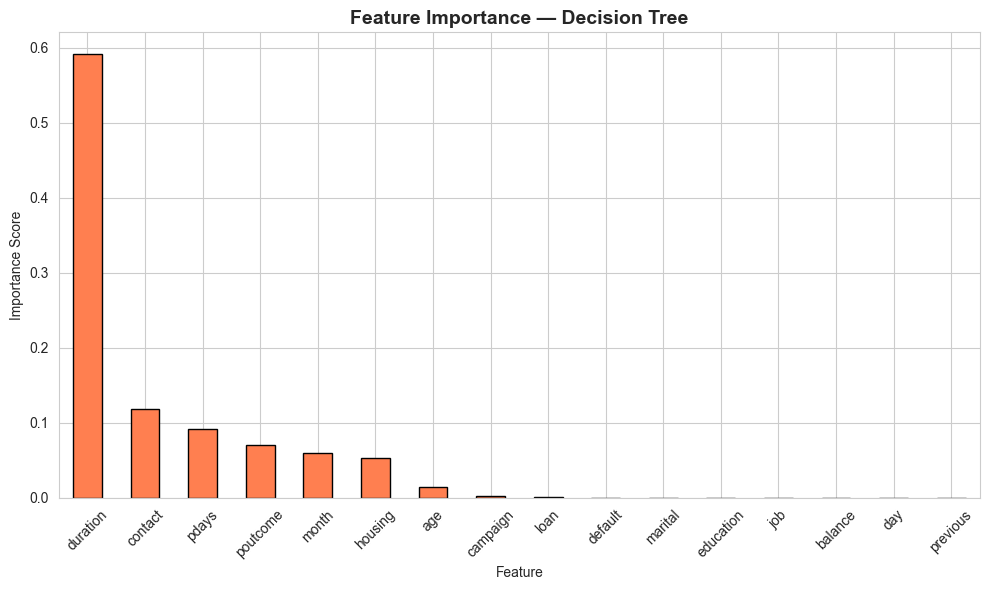


Top 5 Most Important Features:
duration    0.590884
contact     0.118019
pdays       0.091840
poutcome    0.070537
month       0.059281
dtype: float64


In [52]:
# 6.3 Feature Importance — Decision Tree
feature_importance = pd.Series(
    dt_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_importance.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Feature Importance — Decision Tree', fontsize=14, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('\nTop 5 Most Important Features:')
print(feature_importance.head())

## 7. Business Insight Extraction

Based on the EDA and model results, we can now identify which customer segments are most likely to accept the loan offer.

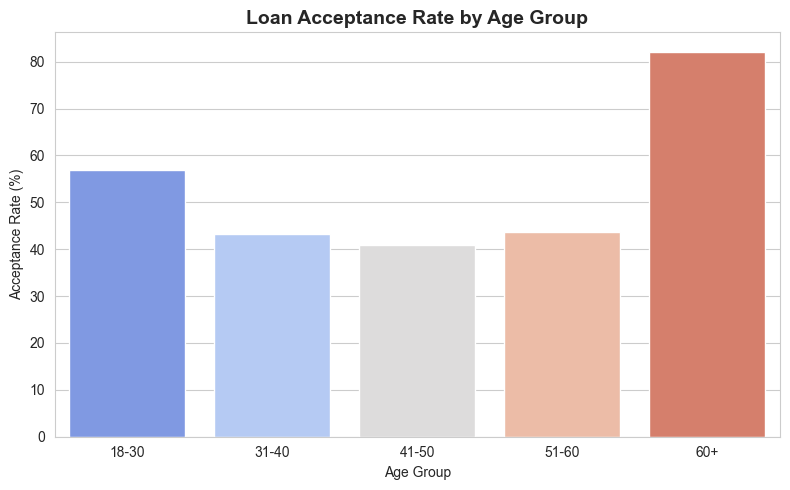

  Age Group  Acceptance Rate (%)
0     18-30            56.928464
1     31-40            43.266476
2     41-50            40.825321
3     51-60            43.602151
4       60+            82.160393


In [53]:
# 7.1 Acceptance rate by age group
df['age_group'] = pd.cut(df['age'], bins=[18, 30, 40, 50, 60, 100],
                          labels=['18-30', '31-40', '41-50', '51-60', '60+'])

age_acceptance = df.groupby('age_group')['deposit'].apply(
    lambda x: (x == 'yes').sum() / len(x) * 100
).reset_index()
age_acceptance.columns = ['Age Group', 'Acceptance Rate (%)']

plt.figure(figsize=(8, 5))
sns.barplot(data=age_acceptance, x='Age Group', y='Acceptance Rate (%)', palette='coolwarm')
plt.title('Loan Acceptance Rate by Age Group', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(age_acceptance)

In [54]:
# 7.2 Acceptance rate by marital status
marital_acceptance = df.groupby('marital')['deposit'].apply(
    lambda x: (x == 'yes').sum() / len(x) * 100
).reset_index()
marital_acceptance.columns = ['Marital Status', 'Acceptance Rate (%)']

print('Acceptance Rate by Marital Status:')
print(marital_acceptance.sort_values('Acceptance Rate (%)', ascending=False))

Acceptance Rate by Marital Status:
  Marital Status  Acceptance Rate (%)
2         single            54.349062
0       divorced            48.105182
1        married            43.378995


In [55]:
# 7.3 Acceptance rate by job type
job_acceptance_rate = df.groupby('job')['deposit'].apply(
    lambda x: (x == 'yes').sum() / len(x) * 100
).reset_index()
job_acceptance_rate.columns = ['Job', 'Acceptance Rate (%)']

print('Acceptance Rate by Job Type:')
print(job_acceptance_rate.sort_values('Acceptance Rate (%)', ascending=False))

Acceptance Rate by Job Type:
              Job  Acceptance Rate (%)
8         student            74.722222
5         retired            66.323907
10     unemployed            56.582633
4      management            50.701481
11        unknown            48.571429
0          admin.            47.301349
6   self-employed            46.172840
9      technician            46.077894
7        services            39.978332
3       housemaid            39.781022
2    entrepreneur            37.500000
1     blue-collar            36.419753


## 8. Conclusion

### Summary of Results

| Model | Accuracy |
|-------|----------|
| Logistic Regression | 78.59% |
| Decision Tree | 80.70% |

### Key Findings

**1. Class Imbalance:**
The dataset is relatively balanced (52.6% No vs 47.4% Yes).We applied stratified sampling to preserve this balance across train and test sets.

**2. Most Predictive Feature:**
Call `duration` (length of last phone call) is the strongest predictor customers who stayed on the call longer were significantly more likely to accept. This is consistent across both models.

**3. Customer Segments Most Likely to Accept:**
- **Age:** Younger customers (18–30) and retirees (60+) showed higher acceptance rates
- **Job:** Students and retired individuals accepted at higher rates than blue-collar workers
- **Marital Status:** Single customers had a slightly higher acceptance rate than married ones

**4. Model Comparison:**
- Logistic Regression is more stable and less prone to overfitting
- Decision Tree provides interpretable feature importance, useful for business decisions
- Both models perform similarly on accuracy, but should be evaluated on recall for the minority class in real deployment

**5. Business Recommendation:**
The bank should prioritize marketing calls to **single, younger or retired customers** and train call agents to extend conversation duration, as longer calls strongly correlate with acceptance. Future campaigns could also use this model to pre screen high probability customers before calling, reducing cost per acquisition.

---
*Task 5 Developers Hub Corporation Internship*